In [1]:
import pandas as pd
import seaborn as sns
import os
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics.pairwise import cosine_similarity
from tqdm import tqdm
import matplotlib.patches as mpatches
from utils import *
import matplotlib.colors as mcolors



In [2]:
def visualize(dimensions, problems, algorithms, runs, line_plot_y=False, plot_y=False, data_dir=None, save=False):
    if data_dir is None:
        data_dir=f'data/clustering_features_x_only'
    for dimension in dimensions:
        directory=f'{data_dir}/cluster_distributions/dim_{dimension}'
        for problem in problems:
            cluster_centers=pd.read_csv(f'{data_dir}/cluster_centers/dim_{dimension}/{problem}.csv',index_col=0)
            
            print(cluster_centers)
            cluster_centers = {index: ', '.join([ str(round(row[c],2)) for c in row.keys()]) for index, row in cluster_centers.iterrows()}
            print(cluster_centers)
            solutions=pd.read_parquet(f'{data_dir}/clustering_results/dim_{dimension}/{problem}.parquet')
            file_loc=f'{directory}/{problem}.csv'
            if os.path.isfile(file_loc):
                df=pd.read_csv(file_loc,index_col=[0,1,2])
                df.columns=[f'{int(c)} (Center: {cluster_centers[int(c)]})' for c in df.columns]
                for a in algorithms:
                    for run in runs:
                        print(problem,a,run)

                        s = solutions.query('algorithm==@a and run==@run').groupby(['iteration', 'cluster'])['scaled_raw_y']
                        s_min=s.min().cummin().to_frame().reset_index()
                        print(s_min)
                        #s_mean=s.mean().to_frame().reset_index()
                        #s_stats = pd.concat([s_min.assign(stat='min'), s_mean.assign(stat='mean')])
                        
                        # Create a figure with subplots
                        fig, axes = plt.subplots(1, 2 if plot_y else 1, figsize=(15 if plot_y else 7, int(s_min['iteration'].max() / 3 )), squeeze=False)
                        axes=axes[0]
                        print(axes[0])

                        # Plot the line plot on the first axis

                        if plot_y:
                            if line_plot_y:
                                sns.lineplot(data=s_min, x='iteration', y='scaled_raw_y', hue='cluster', style='cluster',palette='tab10',markers=True, dashes=False, ax=axes[1])
                                ax1.set_title('Minimum scaled y per cluster and iteration')
                                ax1.set_xlabel('Iteration')
                                ax1.set_ylabel('Scaled Raw Y')
                            else:
                                s_min_pivoted=s_min.pivot(index='iteration', columns='cluster', values='scaled_raw_y')
                                s_min_pivoted.columns=[f'{int(c)} (Center: {cluster_centers[int(c)]})' for c in s_min_pivoted.columns]
                                sns.heatmap(s_min_pivoted, annot=True,ax=axes[1],cmap="YlGnBu", fmt=".3f",norm=mcolors.LogNorm())
                        
                        # Plot the heatmap on the second axis
                        sns.heatmap(df.loc[a, run].replace(0,np.nan), annot=True, ax=axes[0],cmap='YlGnBu')

                        
                        # Adjust layout
                        plt.tight_layout()
                        if save:
                            file_name=f'{problem}_{a}_run_{run}.pdf'
                            plt.savefig('figures_clustering_new/{file_name}',bbox_inches=0)
                        # Show the combined plot
                        plt.show()
                        
                        '''plt.figure()
                        sns.lineplot(s,x='iteration',y='scaled_raw_y', hue='cluster',palette='tab10')
                        plt.show()
                        
                        plt.figure(figsize=(5,dimension*2))
                        sns.heatmap(df.loc[a,run].T,annot=True)
                        plt.show()'''

In [ ]:
def visualize_multi(dimensions, problems, algorithms, runs, line_plot_y=False, plot_y=False, data_dir=None, save=False, popsize=50):
    if data_dir is None:
        data_dir=f'data/clustering_features_x_only'
    for dimension in dimensions:
        directory=f'{data_dir}/cluster_distributions/dim_{dimension}'
        for problem in problems:
            cluster_centers=pd.read_csv(f'{data_dir}/cluster_centers/dim_{dimension}/{problem}.csv',index_col=0)
            print(cluster_centers)
            cluster_count=cluster_centers.shape[0]
            cluster_centers = {index: ', '.join([ str(round(row[c],2)) for c in row.keys()]) for index, row in cluster_centers.iterrows()}
            print(cluster_centers)
            solutions=pd.read_parquet(f'{data_dir}/clustering_results/dim_{dimension}/{problem}.parquet')
            file_loc=f'{directory}/{problem}.csv'
            if os.path.isfile(file_loc):
                df=pd.read_csv(file_loc,index_col=[0,1,2])
                df.columns=[f'{int(c)} (Center: {cluster_centers[int(c)]})' for c in df.columns]
                fig, all_axes = plt.subplots(len(algorithms), 2 if plot_y else 1, figsize=(cluster_count if plot_y else 10, 3*dimension * len(algorithms)), squeeze=False, sharex=True)
                for a_index, a in enumerate(algorithms):
                    for run in runs:
                        print(problem,a,run)

                        s = solutions.query('algorithm==@a and run==@run').groupby(['iteration', 'cluster'])['scaled_raw_y']
                        s_min=s.min().to_frame().reset_index()
                        #s_mean=s.mean().to_frame().reset_index()
                        #s_stats = pd.concat([s_min.assign(stat='min'), s_mean.assign(stat='mean')])
                        
                        # Create a figure with subplots
                        #fig, axes = plt.subplots(1, 2 if plot_y else 1, figsize=(15 if plot_y else 7, int(s_min['iteration'].max() / 3 )), squeeze=False)
                        axes=all_axes[a_index]

                        # Plot the line plot on the first axis
                        axes[0].set_title(f'Algorithm: {a}; Run: {run}')
                        if plot_y:
                            if line_plot_y:
                                sns.lineplot(data=s_min, x='iteration', y='scaled_raw_y', hue='cluster', style='cluster',palette='tab10',markers=True, dashes=False, ax=axes[1])
                                axes[1].set_title('Minimum scaled y per cluster and iteration')
                                axes[1].set_xlabel('Iteration')
                                axes[1].set_ylabel('Scaled Raw Y')
                            else:
                                s_min_pivoted=s_min.pivot(index='iteration', columns='cluster', values='scaled_raw_y')
                                s_min_pivoted.columns=[f'{int(c)} (Center: {cluster_centers[int(c)]})' for c in s_min_pivoted.columns]
                                sns.heatmap(s_min_pivoted, annot=True,ax=axes[1], vmin=0, vmax=1)
                        
                        # Plot the heatmap on the second axis
                        sns.heatmap(df.loc[a, run].replace(0,np.nan), annot=True, ax=axes[0], vmin=0, vmax=popsize,cmap='YlGnBu')

                        
                        # Adjust layout
                
                plt.tight_layout()
                plt.margins(0, tight=True)
                if save:
                    file_name=f"{data_dir.split('/')[-1]}_{problem}_{'+'.join(algorithms)}_run_{'+'.join([str(r) for r in runs])}.pdf"
                    plt.savefig(f'figures_clustering_new/{file_name}',bbox_inches='tight', pad_inches=0)
                # Show the combined plot
                plt.show()

    scaled_x0  scaled_x1
0   -0.903541  -1.126234
1   -0.854848  -1.402573
2   -0.871371  -1.249775
3   -1.039946  -0.804526
4   -0.751289  -1.591658
5   -1.560385  -0.829592
6   -0.930123  -0.905270
7   -0.849707  -1.721219
8   -1.185712  -1.412266
9   -0.920694  -1.065140
10  -0.837011  -1.354036
11  -0.617135  -1.005725
12  -0.896434  -1.175403
13  -0.933901  -0.678591
14  -0.873037  -2.177091
15  -0.812097  -1.492108
16  -1.165099  -0.704201
17  -1.210629  -1.201287
18  -0.550864  -0.559919
19  -1.170513  -1.894573
20  -1.021088  -0.929959
21  -1.530975  -1.493342
22  -0.942082  -0.997853
23  -0.857618  -1.327073
24  -0.827382  -0.982044
25  -0.882329  -1.209481
26  -1.068674  -1.461202
27  -0.823702  -1.555935
28  -1.295335  -0.993648
29  -0.861075  -1.292324
30  -1.598990  -1.011527
31  -0.804103  -1.426550
{0: '-0.9, -1.13', 1: '-0.85, -1.4', 2: '-0.87, -1.25', 3: '-1.04, -0.8', 4: '-0.75, -1.59', 5: '-1.56, -0.83', 6: '-0.93, -0.91', 7: '-0.85, -1.72', 8: '-1.19, -1.41', 9: '-0

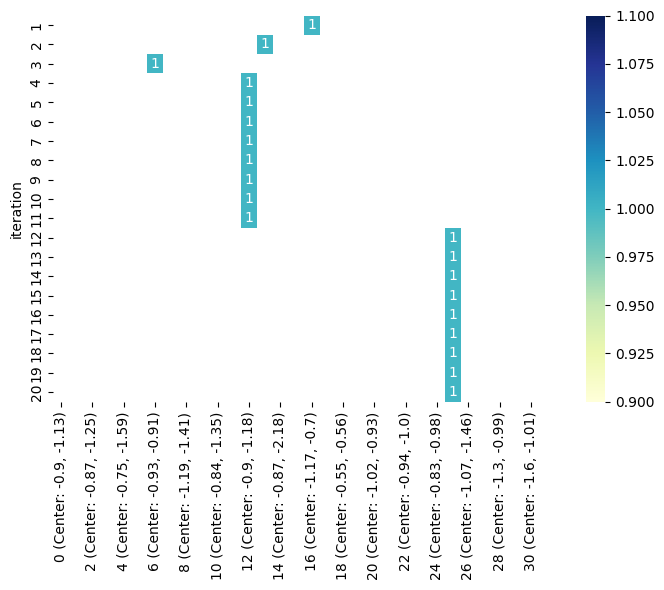

F14_I1 AugmentedAEO 2
    iteration  cluster  scaled_raw_y
0           1        8      0.410751
1           2       10      0.065236
2           3       10      0.001364
3           4       10      0.001363
4           5       10      0.001347
5           6       23      0.001073
6           7       23      0.001000
7           8       23      0.000978
8           9       29      0.000346
9          10       29      0.000251
10         11       29      0.000246
11         12        2      0.000065
12         13        2      0.000038
13         14        2      0.000014
14         15        2      0.000012
15         16        2      0.000012
16         17        2      0.000012
17         18        2      0.000012
18         19        2      0.000012
19         20        2      0.000012
Axes(0.125,0.11;0.775x0.77)


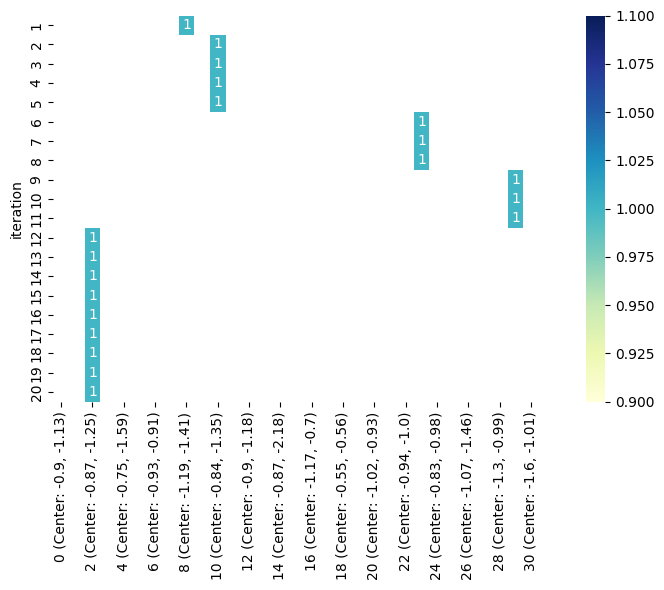

F14_I1 AugmentedAEO 3
    iteration  cluster  scaled_raw_y
0           1       27      0.106018
1           2       27      0.083211
2           3       22      0.018681
3           4        9      0.008691
4           5        9      0.007742
5           6        0      0.002103
6           7        0      0.002004
7           8       12      0.000862
8           9        2      0.000098
9          10        2      0.000012
10         11        2      0.000002
11         12        2      0.000001
12         13        2      0.000001
13         14        2      0.000001
14         15        2      0.000001
15         16        2      0.000001
16         17        2      0.000001
17         18        2      0.000001
18         19        2      0.000001
19         20        2      0.000001
Axes(0.125,0.11;0.775x0.77)


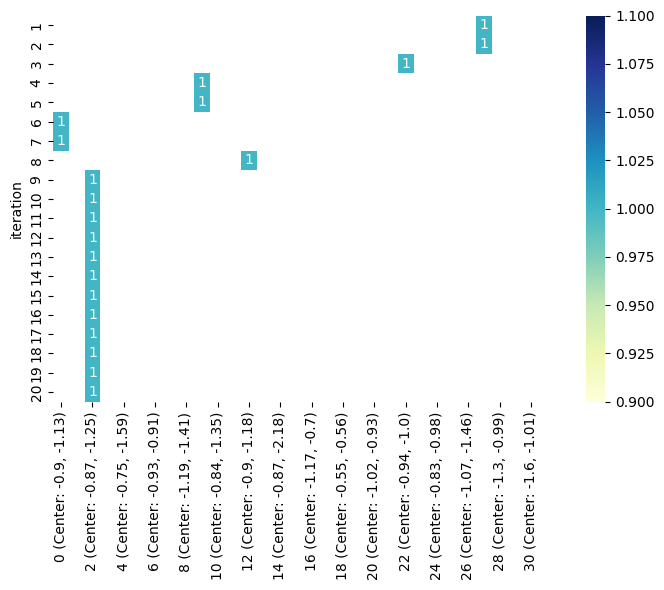

F14_I1 AugmentedAEO 4
    iteration  cluster  scaled_raw_y
0           1       20      0.070057
1           2       22      0.024964
2           3       22      0.018923
3           4       22      0.016881
4           5        9      0.014749
5           6        9      0.007797
6           7        9      0.005821
7           8        0      0.003515
8           9       25      0.000135
9          10       25      0.000130
10         11       25      0.000127
11         12       25      0.000126
12         13       25      0.000110
13         14       25      0.000109
14         15       25      0.000106
15         16       25      0.000105
16         17       25      0.000101
17         18       25      0.000100
18         19       25      0.000095
19         20       25      0.000088
Axes(0.125,0.11;0.775x0.77)


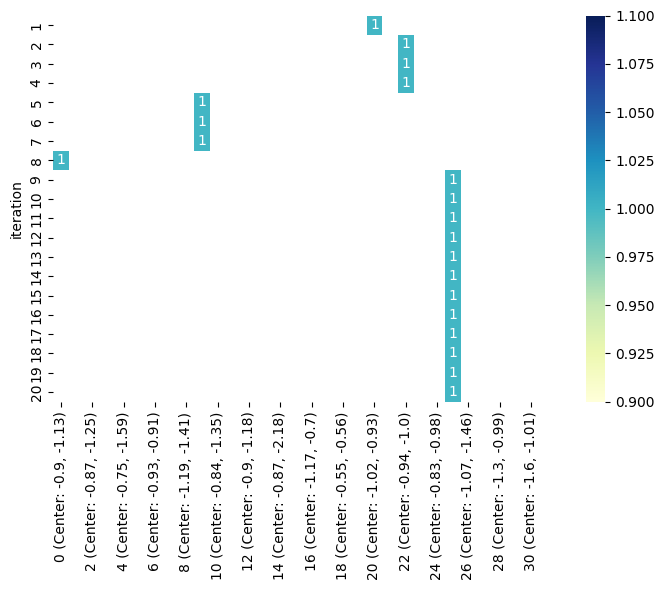

F14_I1 AugmentedAEO 5
    iteration  cluster  scaled_raw_y
0           1        6      0.108776
1           2       15      0.026164
2           3       31      0.007030
3           4       10      0.005383
4           5       23      0.000952
5           6       23      0.000600
6           7       29      0.000178
7           8       29      0.000174
8           9       29      0.000173
9          10       29      0.000170
10         11       29      0.000169
11         12       29      0.000168
12         13       29      0.000159
13         14       29      0.000145
14         15       29      0.000031
15         16        2      0.000016
16         17        2      0.000016
17         18        2      0.000016
18         19        2      0.000015
19         20        2      0.000015
Axes(0.125,0.11;0.775x0.77)


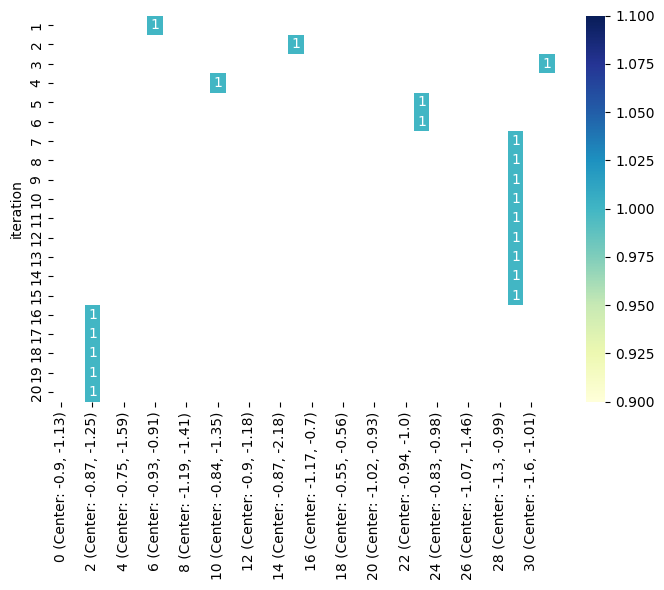

F14_I1 OriginalDE 1
    iteration  cluster  scaled_raw_y
0           1        7      0.234854
1           2        7      0.234854
2           3        7      0.234854
3           4        7      0.191265
4           5       27      0.040567
5           6       27      0.040567
6           7       27      0.040567
7           8       15      0.026217
8           9       15      0.024365
9          10       15      0.020257
10         11       15      0.019328
11         12       31      0.014082
12         13       31      0.014082
13         14       31      0.010955
14         15       31      0.010085
15         16       31      0.010085
16         17       31      0.009914
17         18       31      0.009761
18         19       31      0.009737
19         20       31      0.009658
Axes(0.125,0.11;0.775x0.77)


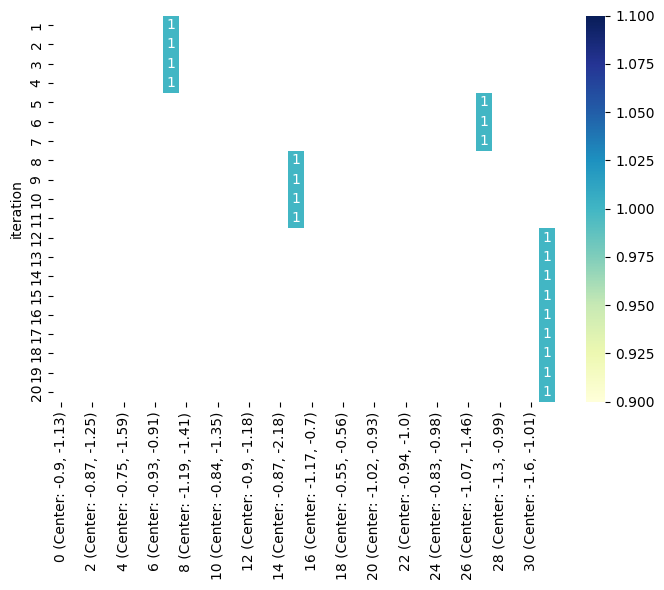

F14_I1 OriginalDE 2
    iteration  cluster  scaled_raw_y
0           1        8      0.503800
1           2       26      0.263831
2           3       26      0.263831
3           4       10      0.006841
4           5       10      0.006841
5           6       10      0.006841
6           7       10      0.005495
7           8       10      0.005495
8           9       10      0.004486
9          10       10      0.003253
10         11       10      0.002401
11         12       10      0.001537
12         13       10      0.001537
13         14       10      0.001529
14         15       10      0.001504
15         16       10      0.001504
16         17       10      0.001396
17         18       10      0.001335
18         19       10      0.001315
19         20       10      0.001315
Axes(0.125,0.11;0.775x0.77)


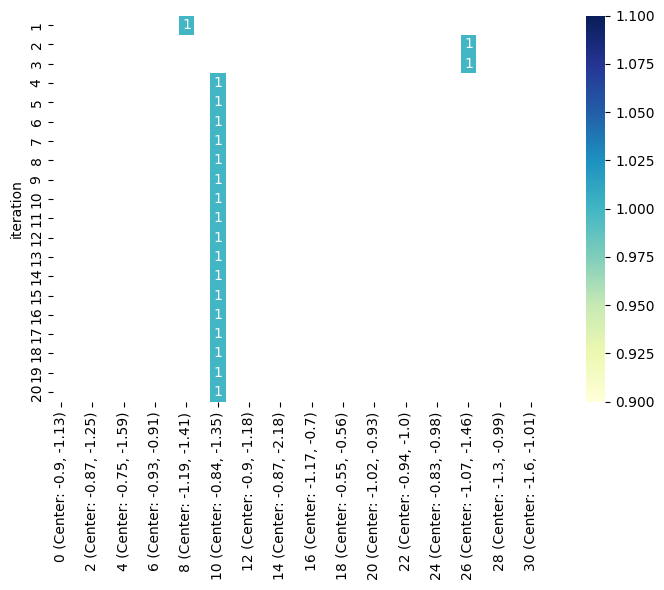

F14_I1 OriginalDE 3
    iteration  cluster  scaled_raw_y
0           1       16  3.874922e-01
1           2       16  3.874922e-01
2           3        9  5.813476e-02
3           4        9  5.813476e-02
4           5        0  1.089579e-02
5           6        0  4.721021e-03
6           7        0  4.721021e-03
7           8       23  9.743994e-04
8           9       23  9.743994e-04
9          10       23  7.553771e-04
10         11       29  3.495339e-04
11         12       29  3.062388e-04
12         13        2  2.396918e-04
13         14        2  1.582434e-04
14         15        2  7.149667e-05
15         16        2  6.827120e-05
16         17        2  9.522808e-06
17         18        2  3.842073e-06
18         19        2  2.955290e-06
19         20        2  8.422233e-07
Axes(0.125,0.11;0.775x0.77)


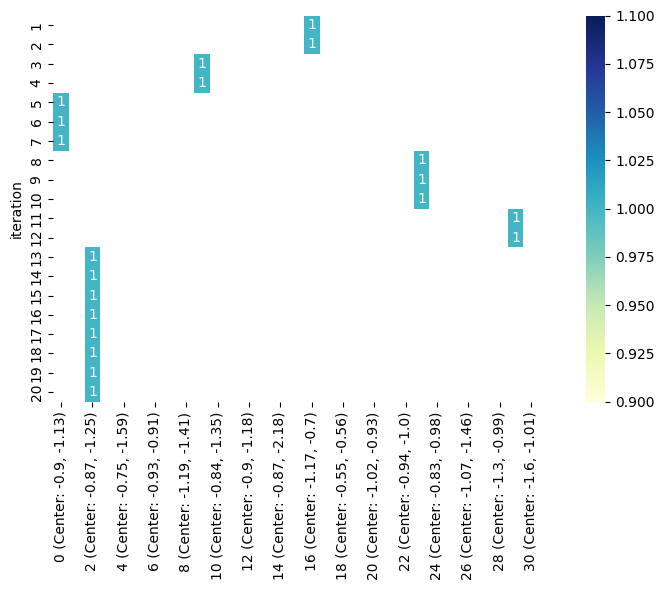

F14_I1 OriginalDE 4
    iteration  cluster  scaled_raw_y
0           1       27      0.099452
1           2       27      0.099452
2           3       27      0.099452
3           4       27      0.099452
4           5       27      0.099452
5           6        2      0.000401
6           7        2      0.000401
7           8        2      0.000401
8           9        2      0.000401
9          10        2      0.000401
10         11        2      0.000401
11         12        2      0.000401
12         13        2      0.000401
13         14        2      0.000401
14         15        2      0.000352
15         16        2      0.000352
16         17       12      0.000338
17         18       25      0.000212
18         19       25      0.000170
19         20       25      0.000162
Axes(0.125,0.11;0.775x0.77)


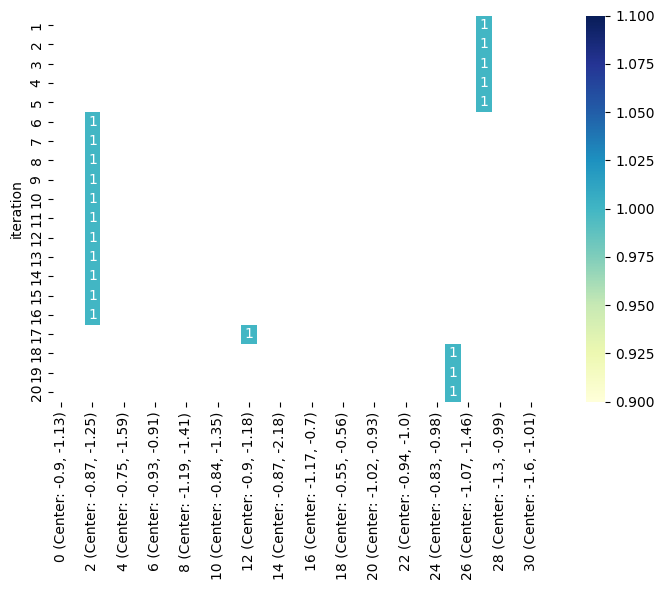

F14_I1 OriginalDE 5
    iteration  cluster  scaled_raw_y
0           1        5      0.767397
1           2        5      0.767397
2           3        5      0.767397
3           4        5      0.767397
4           5       16      0.327896
5           6        3      0.161763
6           7        9      0.017036
7           8        9      0.017036
8           9        0      0.005754
9          10        0      0.005754
10         11        0      0.005754
11         12        0      0.004962
12         13        0      0.004330
13         14        0      0.004330
14         15        0      0.004330
15         16        0      0.003865
16         17        0      0.003799
17         18        0      0.003499
18         19        0      0.003499
19         20        0      0.003499
Axes(0.125,0.11;0.775x0.77)


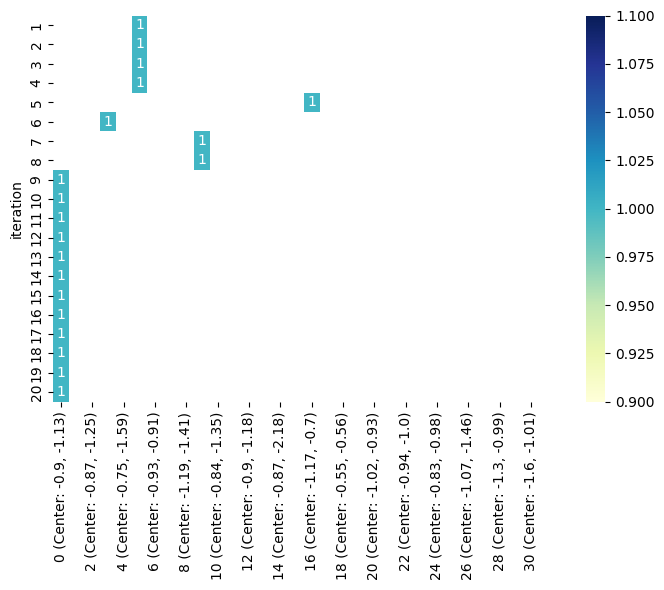

In [5]:
visualize([2], ['F14_I1'], ['AugmentedAEO','OriginalDE'], [1,2,3,4, 5], data_dir=f'data/clustering_features_x_only_10_algorithms_kmeans_2pow_no_init', plot_y=False)

In [370]:
algorithms_of_interest=["ModifiedAEO",
"EnhancedAEO",
"OriginalAEO",
"AugmentedAEO",
"SHADE",
"SADE",
"JADE",
"BaseDE",
"OriginalWOA",
"HI_WOA"]

    scaled_x0  scaled_x1
0   -2.808012   0.973159
1   -4.686164  -4.550776
2    4.588092   0.687825
3   -3.785796   0.659193
4   -4.862515   0.338185
5   -0.306911   1.690473
6   -1.632894   1.352088
7    3.290653   0.240075
8   -3.530718   0.736332
9   -4.465097   0.452166
10  -3.111586   0.874805
11  -4.036395   0.575293
12  -2.269846   1.125729
13  -4.379062  -4.349965
14  -1.133696   1.466896
15   4.293191   0.522146
{0: '-2.81, 0.97', 1: '-4.69, -4.55', 2: '4.59, 0.69', 3: '-3.79, 0.66', 4: '-4.86, 0.34', 5: '-0.31, 1.69', 6: '-1.63, 1.35', 7: '3.29, 0.24', 8: '-3.53, 0.74', 9: '-4.47, 0.45', 10: '-3.11, 0.87', 11: '-4.04, 0.58', 12: '-2.27, 1.13', 13: '-4.38, -4.35', 14: '-1.13, 1.47', 15: '4.29, 0.52'}
F22_I4 OriginalWOA 2
F22_I4 HI_WOA 2


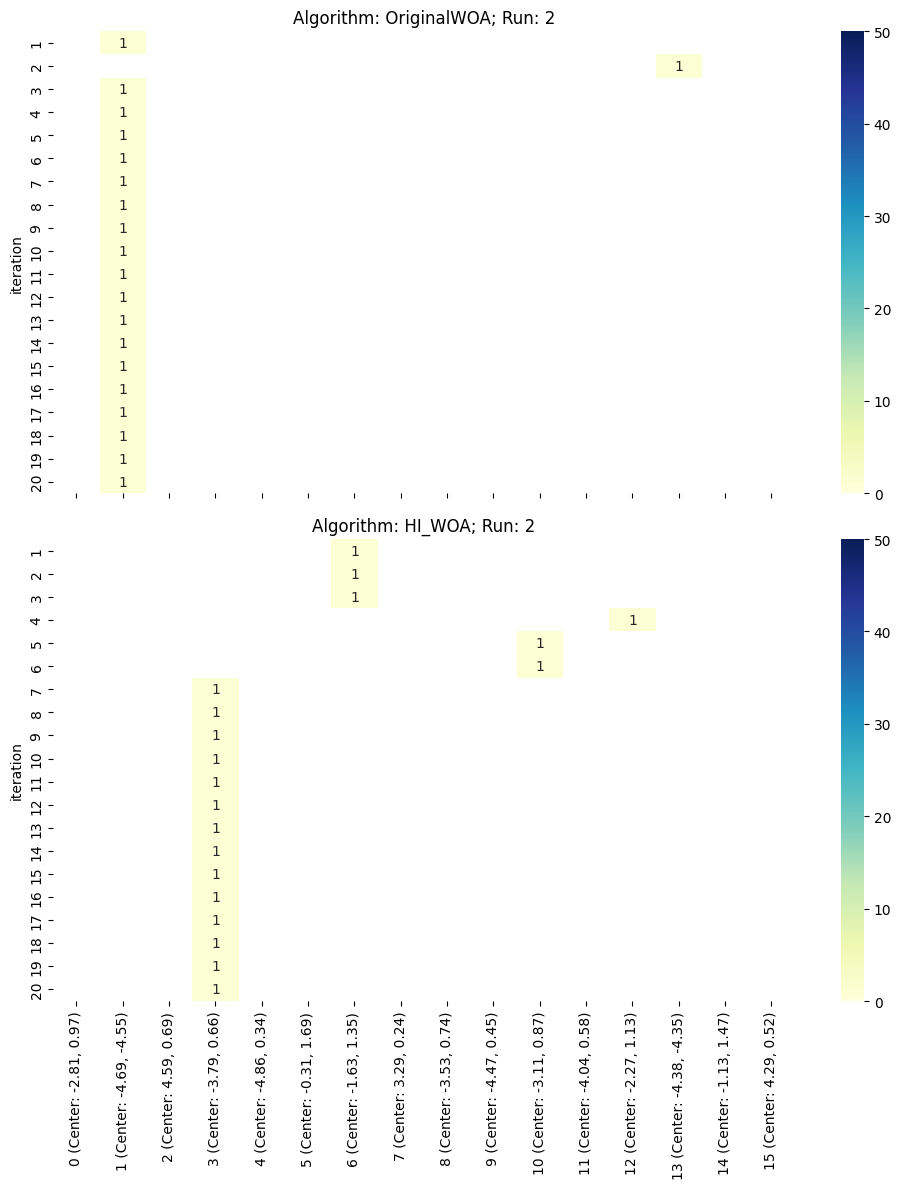

In [7]:
visualize_multi([2], ['F22_I4'], ["OriginalWOA","HI_WOA"], [2], data_dir=f'data/clustering_features_x_only_10_algorithms_kmeans_2pow_no_init', save=False)

    scaled_x0  scaled_x1
0    4.042022  -3.846723
1    0.309186  -0.987697
2   -3.082118   1.610571
3    2.278731  -2.490763
4   -1.284487   0.233263
5   -4.818711   2.944991
6    1.197079  -1.667722
7   -0.247055  -0.561440
8    0.676136  -1.268433
9    3.080997  -3.111814
10  -2.314868   1.025320
11   4.851576  -4.473459
12  -0.739837  -0.187428
13   0.055595  -0.792672
14  -1.653965   0.507209
15  -3.735740   2.098962
{0: '4.04, -3.85', 1: '0.31, -0.99', 2: '-3.08, 1.61', 3: '2.28, -2.49', 4: '-1.28, 0.23', 5: '-4.82, 2.94', 6: '1.2, -1.67', 7: '-0.25, -0.56', 8: '0.68, -1.27', 9: '3.08, -3.11', 10: '-2.31, 1.03', 11: '4.85, -4.47', 12: '-0.74, -0.19', 13: '0.06, -0.79', 14: '-1.65, 0.51', 15: '-3.74, 2.1'}
F10_I3 JADE 1
    iteration  cluster  scaled_raw_y
0           1        5      0.105438
1           2        5      0.105438
2           3        5      0.105438
3           4        6      0.000317
4           5        6      0.000317
5           6        6      0.000317
6      

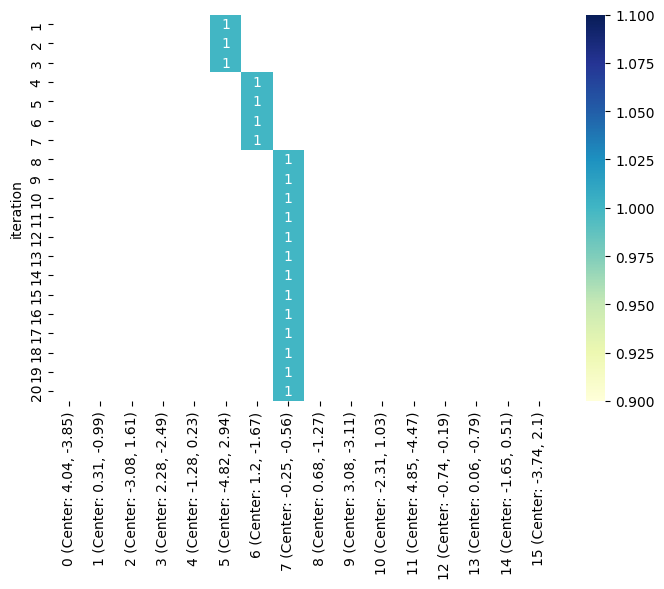

F10_I3 JADE 2
    iteration  cluster  scaled_raw_y
0           1       14      0.886383
1           2        1      0.000030
2           3        1      0.000030
3           4        1      0.000030
4           5        1      0.000030
5           6        1      0.000030
6           7        1      0.000030
7           8        1      0.000030
8           9        1      0.000030
9          10        1      0.000030
10         11        1      0.000030
11         12        1      0.000030
12         13        1      0.000030
13         14        1      0.000005
14         15        1      0.000005
15         16        1      0.000005
16         17        1      0.000005
17         18        1      0.000005
18         19        1      0.000005
19         20        1      0.000005
Axes(0.125,0.11;0.775x0.77)


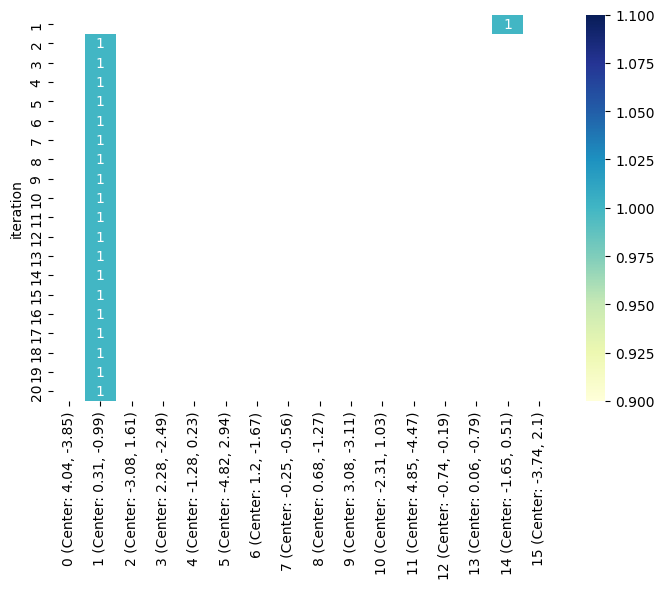

F10_I3 JADE 3
    iteration  cluster  scaled_raw_y
0           1        6      0.224287
1           2       10      0.049883
2           3       10      0.049883
3           4        3      0.000264
4           5        3      0.000264
5           6        3      0.000264
6           7        3      0.000264
7           8        3      0.000264
8           9        3      0.000264
9          10        3      0.000264
10         11        3      0.000264
11         12        8      0.000110
12         13        8      0.000110
13         14        8      0.000110
14         15        8      0.000110
15         16        1      0.000015
16         17        1      0.000015
17         18        1      0.000015
18         19        1      0.000015
19         20        1      0.000015
Axes(0.125,0.11;0.775x0.77)


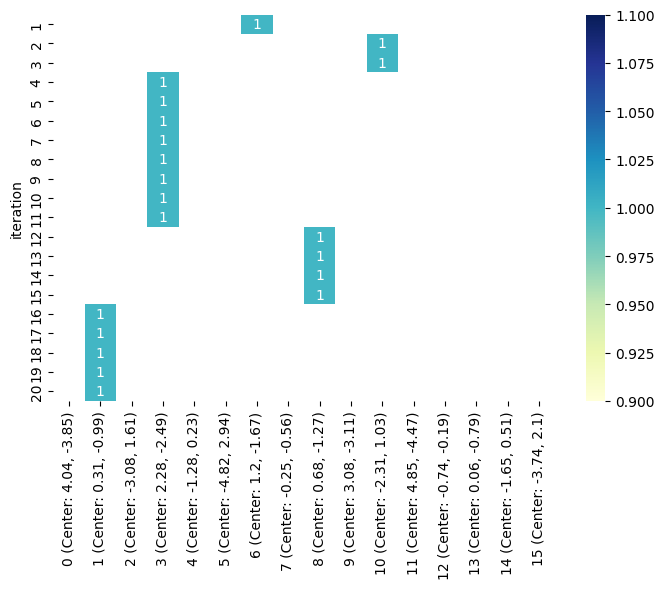

F10_I3 SADE 1
    iteration  cluster  scaled_raw_y
0           1        5      0.215612
1           2       10      0.010031
2           3       10      0.010031
3           4       10      0.010031
4           5       10      0.000282
5           6       10      0.000282
6           7       10      0.000282
7           8       10      0.000282
8           9       10      0.000282
9          10       10      0.000282
10         11       10      0.000282
11         12       10      0.000282
12         13        6      0.000066
13         14        6      0.000066
14         15        6      0.000066
15         16        6      0.000066
16         17       12      0.000051
17         18       12      0.000051
18         19       12      0.000051
19         20       12      0.000051
Axes(0.125,0.11;0.775x0.77)


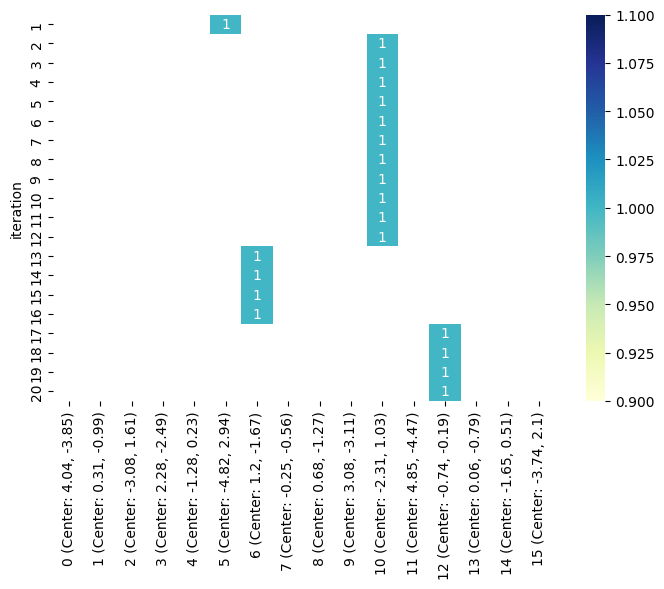

F10_I3 SADE 2
    iteration  cluster  scaled_raw_y
0           1        5      0.003779
1           2        5      0.003779
2           3        5      0.003779
3           4        5      0.003779
4           5        5      0.003779
5           6        5      0.003779
6           7       11      0.001598
7           8        6      0.000785
8           9        6      0.000785
9          10        6      0.000785
10         11        3      0.000591
11         12        3      0.000591
12         13        4      0.000253
13         14        4      0.000253
14         15        4      0.000253
15         16        8      0.000074
16         17        8      0.000074
17         18        8      0.000020
18         19       13      0.000001
19         20       13      0.000001
Axes(0.125,0.11;0.775x0.77)


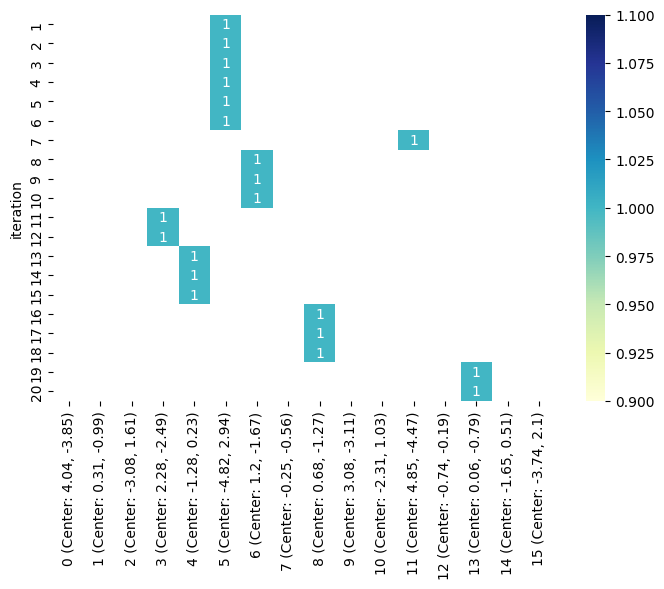

F10_I3 SADE 3
    iteration  cluster  scaled_raw_y
0           1        3      0.013510
1           2        3      0.013510
2           3        3      0.013510
3           4       12      0.005606
4           5       12      0.005606
5           6        1      0.001214
6           7        1      0.001214
7           8        1      0.001214
8           9        1      0.001214
9          10        1      0.001214
10         11        4      0.000148
11         12        4      0.000148
12         13        4      0.000148
13         14        4      0.000148
14         15        4      0.000148
15         16        4      0.000148
16         17        1      0.000011
17         18        1      0.000011
18         19        1      0.000011
19         20        1      0.000011
Axes(0.125,0.11;0.775x0.77)


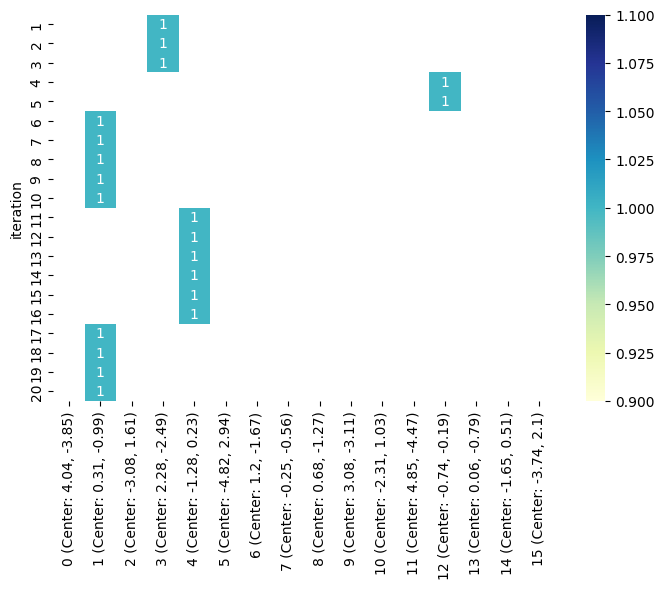

In [9]:
visualize([2], ['F10_I3'], ['JADE','SADE'], [1,2,3],data_dir=f'data/clustering_features_x_only_10_algorithms_kmeans_2pow_no_init', plot_y=False)

In [10]:
dimension=2
directory=f'data/clustering_features_x_only_10_algorithms_kmeans_2pow_no_init/cluster_distributions/dim_{dimension}'

trajectory_similarities=[]
for file in tqdm(os.listdir(directory)):
    file_loc=f'{directory}/{file}'
    if os.path.isfile(file_loc):
        df=pd.read_csv(file_loc,index_col=[0,1,2])
        d_algorithm_run=df.unstack(level=-1).dropna()
        #d_algorithm_run=pd.DataFrame(MinMaxScaler().fit_transform(d_algorithm_run), index=d_algorithm_run.index, columns=d_algorithm_run.columns).dropna()
        cs=pd.DataFrame(cosine_similarity(d_algorithm_run), index=d_algorithm_run.index, columns=d_algorithm_run.index)
        c=cs.reset_index().rename(columns={'algorithm':'algorithm2', 'run':'run2'}).melt(id_vars=[('algorithm2',  ''),('run2',  '')], value_vars=list(cs.columns)).rename(columns={('algorithm2',  ''): 'algorithm2', ('run2',''):'run2'})
        trajectory_similarities+=[c.assign(problem=file.replace('.csv',''))]

trajectory_similarities=pd.concat(trajectory_similarities)
t=trajectory_similarities.groupby('algorithm').count()['run']
t_max=t.max()
algorithms_to_remove=list(t[t<t_max].index)
trajectory_similarities=trajectory_similarities.query('algorithm not in @algorithms_to_remove and algorithm2 not in @algorithms_to_remove')
trajectory_similarities['problem_class']=[int(tt.split('_')[0].replace('F','')) for tt in trajectory_similarities['problem']]
trajectory_similarities['instance']=[int(tt.split('_')[1].replace('I','')) for tt in trajectory_similarities['problem']]

100%|██████████| 120/120 [00:01<00:00, 94.11it/s]


In [11]:
trajectory_similarities.query('algorithm!=algorithm2').sort_values('value')

,algorithm2,run2,algorithm,run,value,problem,problem_class,instance
1828,OriginalDE,4,SADE,1,0.0,F24_I2,24,2
1829,OriginalDE,5,SADE,1,0.0,F24_I2,24,2
1830,OriginalSHADE,1,SADE,1,0.0,F24_I2,24,2
1831,OriginalSHADE,2,SADE,1,0.0,F24_I2,24,2
2013,OriginalSHADE,4,SADE,5,0.0,F9_I4,9,4
...,...,...,...,...,...,...,...,...
666,OriginalWOA,2,JADE,5,1.0,F22_I1,22,1
639,HI_WOA,5,JADE,5,1.0,F22_I1,22,1
1485,AugmentedAEO,1,OriginalSHADE,4,1.0,F23_I2,23,2
867,JADE,3,ModifiedAEO,5,1.0,F24_I2,24,2


100%|██████████| 120/120 [00:01<00:00, 65.72it/s]


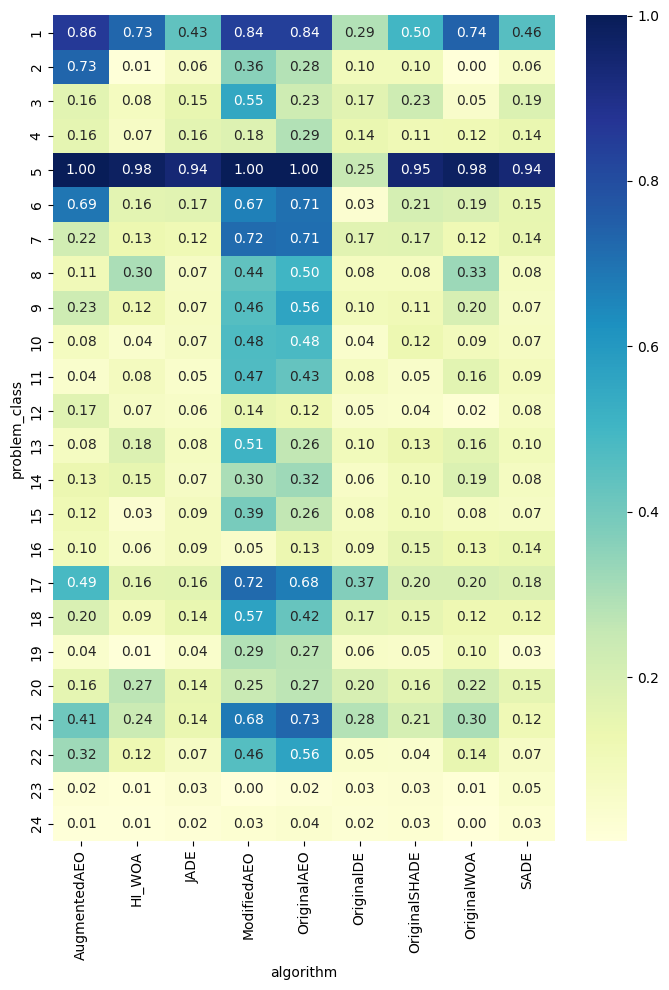

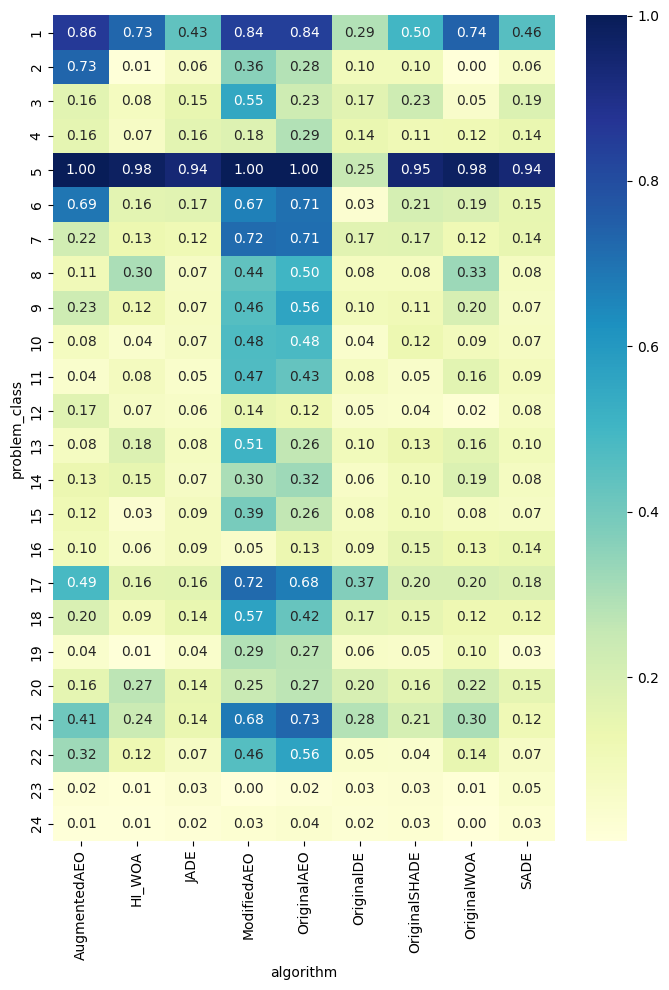

<Figure size 600x600 with 0 Axes>

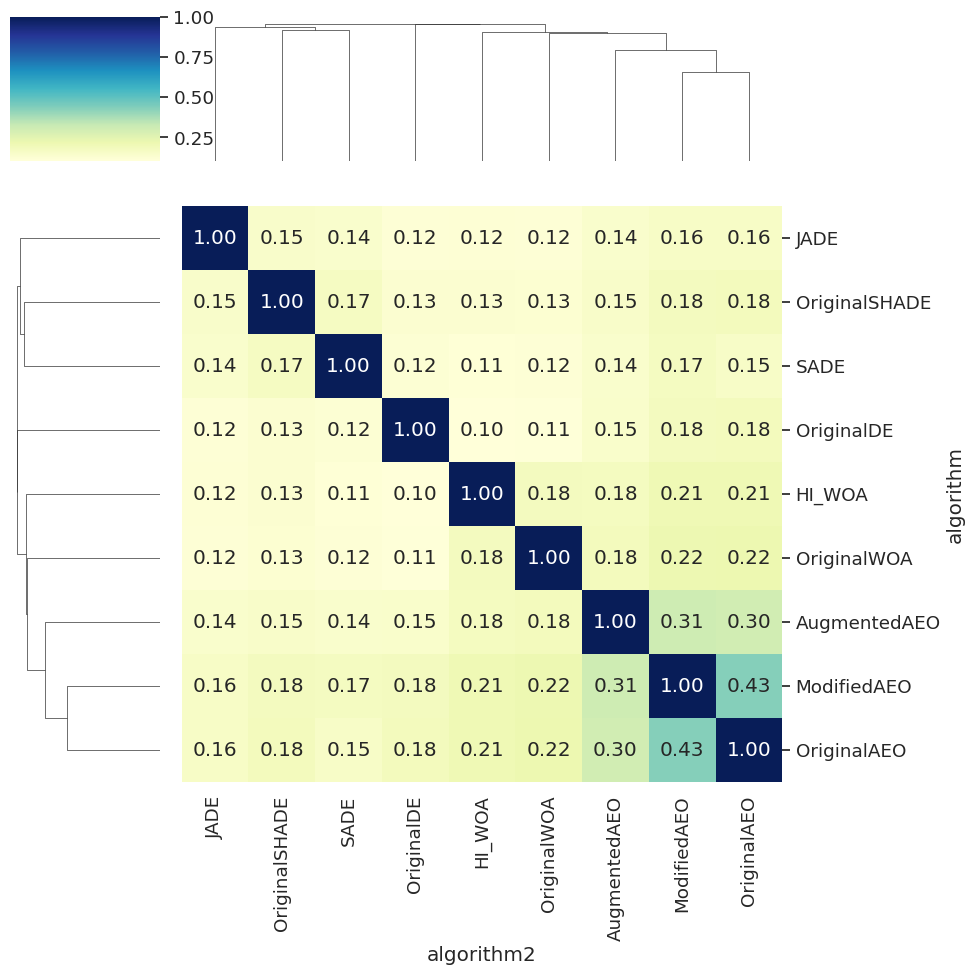

In [13]:
for dimension in [2]:
    directory=f'data/clustering_features_x_only_10_algorithms_kmeans_2pow_no_init/cluster_distributions/dim_{dimension}'
    scale=False
    trajectory_similarities=[]
    for file in tqdm(os.listdir(directory)):
        file_loc=f'{directory}/{file}'
        if os.path.isfile(file_loc):
            df=pd.read_csv(file_loc,index_col=[0,1,2])
            d_algorithm_run=df.unstack(level=-1).dropna()
            d_algorithm_run=pd.DataFrame(MinMaxScaler().fit_transform(d_algorithm_run), index=d_algorithm_run.index, columns=d_algorithm_run.columns).dropna()
            cs=pd.DataFrame(cosine_similarity(d_algorithm_run), index=d_algorithm_run.index, columns=d_algorithm_run.index)
            c=cs.reset_index().rename(columns={'algorithm':'algorithm2', 'run':'run2'}).melt(id_vars=[('algorithm2',  ''),('run2',  '')], value_vars=list(cs.columns)).rename(columns={('algorithm2',  ''): 'algorithm2', ('run2',''):'run2'})
            trajectory_similarities+=[c.assign(problem=file.replace('.csv',''))]
    
    trajectory_similarities=pd.concat(trajectory_similarities)
    t=trajectory_similarities.groupby('algorithm').count()['run']
    t_max=t.max()
    algorithms_to_remove=list(t[t<t_max].index)
    trajectory_similarities=trajectory_similarities.query('algorithm not in @algorithms_to_remove and algorithm2 not in @algorithms_to_remove')
    trajectory_similarities['problem_class']=[int(tt.split('_')[0].replace('F','')) for tt in trajectory_similarities['problem']]
    trajectory_similarities['instance']=[int(tt.split('_')[1].replace('I','')) for tt in trajectory_similarities['problem']]

    plt.figure(figsize=(7,10))
    sim_per_problem_algorithm=trajectory_similarities.query('algorithm==algorithm2 and run!=run2').groupby(['problem_class','algorithm'])['value'].mean()
    sns.heatmap(sim_per_problem_algorithm.reset_index().pivot(index='problem_class',columns='algorithm',values='value').sort_index(),annot=True,fmt=".2f", cmap='YlGnBu')
    plt.tight_layout()
    plt.savefig(f'figures_clustering_new/algorithm_similarity_per_problem_dim_{dimension}_scale_{scale}.pdf')


    plt.figure(figsize=(7,10))
    sim_per_problem_algorithm=trajectory_similarities.query('algorithm==algorithm2 and run!=run2').groupby(['problem_class','algorithm'])['value'].mean()
    sns.heatmap(sim_per_problem_algorithm.reset_index().pivot(index='problem_class',columns='algorithm',values='value').sort_index(),annot=True,fmt=".2f", cmap='YlGnBu')
    plt.tight_layout()
    plt.savefig(f'figures_clustering_new/algorithm_stability_per_problem_dim_{dimension}_scale_{scale}.pdf')

    cross_algorithm_similarity=trajectory_similarities.query('run==run2').groupby(['algorithm','algorithm2'])['value'].mean()
    cross_algorithm_similarity_pivoted=cross_algorithm_similarity.reset_index().pivot(index='algorithm',columns='algorithm2',values='value')
    sns.set(font_scale=1.2)
    plt.figure(figsize=(6,6))
    sns.clustermap(cross_algorithm_similarity_pivoted,annot=True,fmt=".2f", cmap='YlGnBu')
    plt.tight_layout()
    plt.savefig(f'figures_clustering_new/algorithm_mean_similarity_clustermap_dim_{dimension}_scale_{scale}.pdf')
    sns.set(font_scale=1)


In [10]:
optimizer_group=get_algorithm_groups()


In [11]:
cross_algorithm_similarity_to_save=cross_algorithm_similarity.reset_index()
cross_algorithm_similarity_to_save['algorithm_group']=cross_algorithm_similarity_to_save['algorithm'].apply(lambda x: optimizer_group[x])
cross_algorithm_similarity_to_save['algorithm2_group']=cross_algorithm_similarity_to_save['algorithm2'].apply(lambda x: optimizer_group[x])
cross_algorithm_similarity_to_save.sort_values('value',ascending=False).query('algorithm!=algorithm2').to_csv(f'../data/clustering_features/algorithm_pairwise_similarity/algorithm_mean_similarity_{dimension}D.csv')

In [12]:

unique_optimizer_groups=list(set(optimizer_group.values()))
#optimizer_group={k:str(v).split('.')[1] for k,v in optimizers.items()}
unique_colors=list(sns.color_palette("tab10"))
group_color={f:unique_colors[fi] for fi, f in enumerate(unique_optimizer_groups)}

unique_optimizer_groups=list(set(optimizer_group.values()))
#optimizer_group={k:str(v).split('.')[1] for k,v in optimizers.items()}
unique_colors=list(sns.color_palette("tab10"))
group_color={f:unique_colors[fi] for fi, f in enumerate(unique_optimizer_groups)}

/opt/conda/envs/Base/lib/python3.9/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/opt/conda/envs/Base/lib/python3.9/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


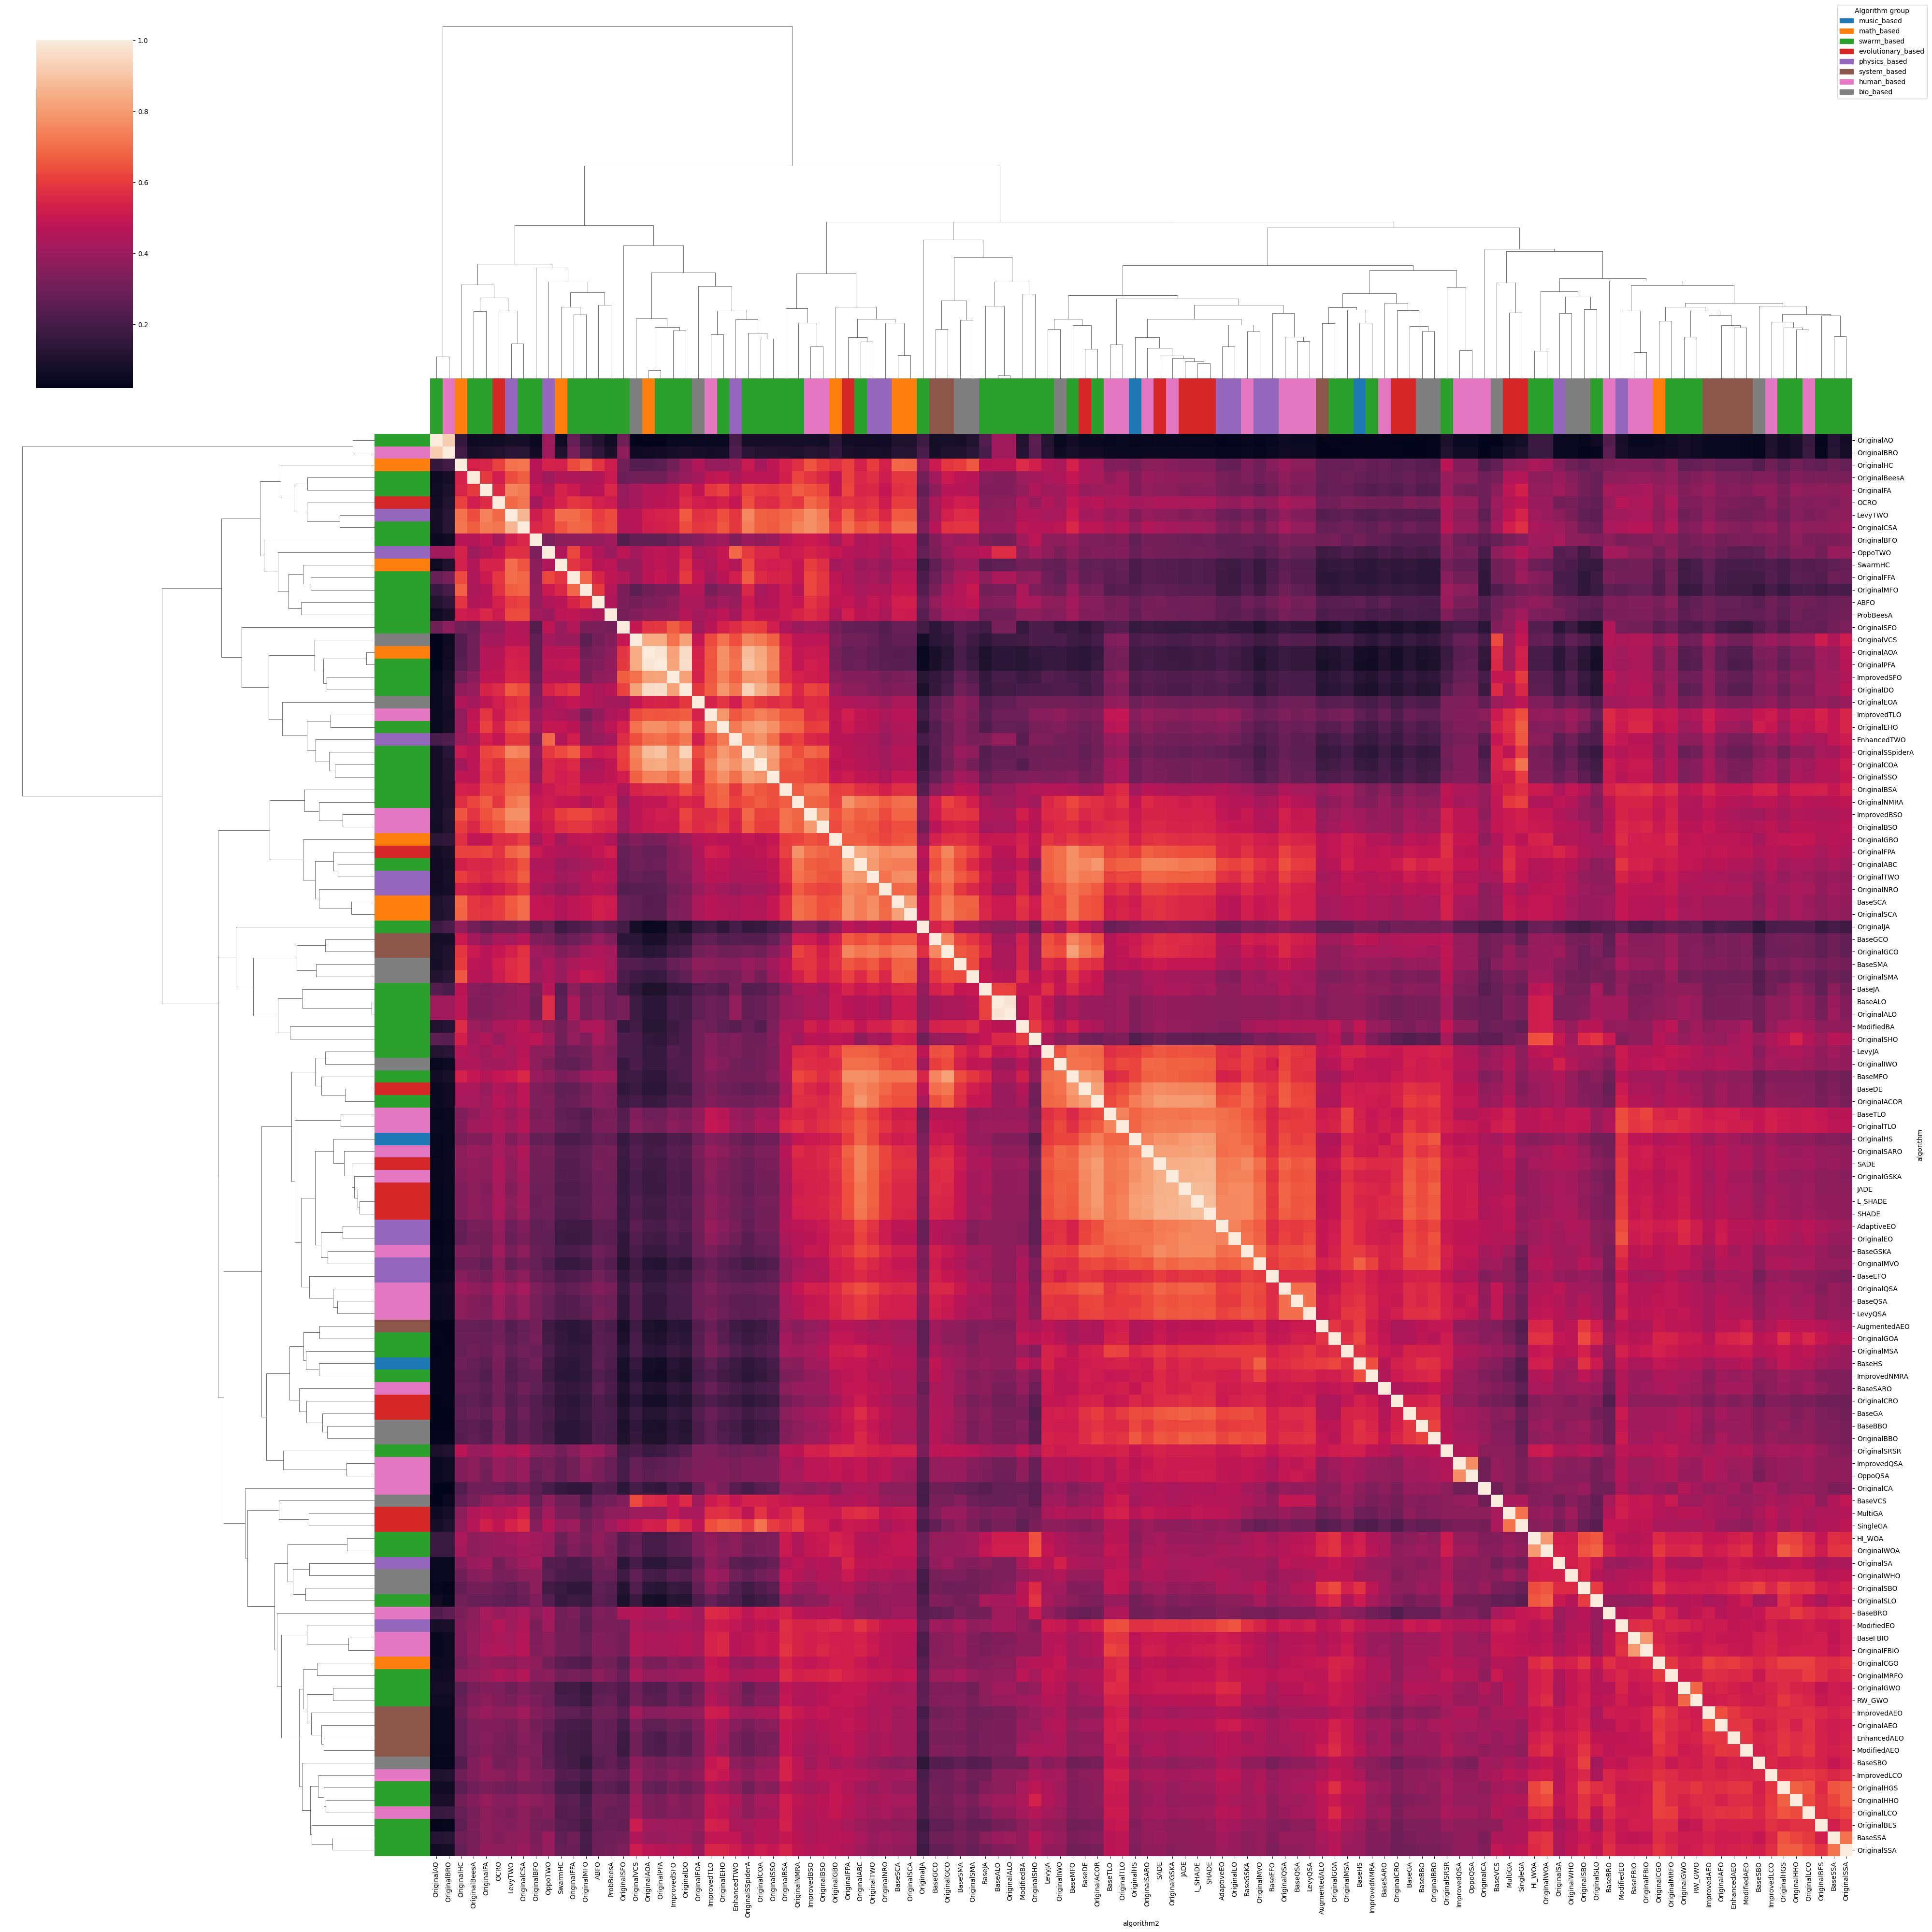

In [13]:
row_colors=[group_color[optimizer_group[o]] for o in cross_algorithm_similarity_pivoted.index]
col_colors=[group_color[optimizer_group[o]] for o in cross_algorithm_similarity_pivoted.columns]
sns.clustermap(cross_algorithm_similarity_pivoted, row_colors=row_colors, col_colors=col_colors,figsize=(40,40))
handles = [mpatches.Patch(color=color, label=label) for label, color in group_color.items()]
# Add legend to the clustermap
plt.legend(handles=handles, title='Algorithm group', bbox_to_anchor=(1, 1), bbox_transform=plt.gcf().transFigure)

plt.savefig(f'figures_clustering/algorithm_mean_similarity_clustermap_dim{dimension}.pdf')
plt.show()
